# Missing values in adaptive n-of-1 trials

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy
from adaptive_nof1 import *
from adaptive_nof1.policies import *
from adaptive_nof1.helpers import *
from adaptive_nof1.inference import *
from adaptive_nof1.metrics import *
from matplotlib import pyplot as plt

import random

import seaborn as sns

import sys
sys.path.append("..")

from missingness.missing_utils import *

from ast import literal_eval

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/mnt/c/Users/Juliana/dev/adaptive_nof1/.env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [152]:
def prep_all_results_df(df_all_results):
        
    df_all_results.reset_index(inplace=True)
    
    df_all_results.drop(columns=["level_0","level_1"],inplace=True)
    
    df_all_results[[f'means_full',f'vars_full']] = pd.DataFrame(df_all_results["posterior_parameters"].tolist(), index= df_all_results.index)
    
    df_all_results[[f'means_miss',f'vars_miss']] = pd.DataFrame(df_all_results["posterior_parameters_miss"].tolist(), index= df_all_results.index)
    
    df_all_results[[f'post_mean_0_full',f'post_mean_1_full']] = pd.DataFrame(df_all_results["means_full"].tolist(), index= df_all_results.index)
    
    df_all_results[[f'post_mean_0_miss',f'post_mean_1_miss']] = pd.DataFrame(df_all_results["means_miss"].tolist(), index= df_all_results.index)
    
    df_all_results[[f'post_var_0_full',f'post_var_1_full']] = pd.DataFrame(df_all_results["vars_full"].tolist(), index= df_all_results.index)
    
    df_all_results[[f'post_var_0_miss',f'post_var_1_miss']] = pd.DataFrame(df_all_results["vars_miss"].tolist(), index= df_all_results.index)
    
    df_all_results.drop(columns=["means_full", "vars_full",
                                "means_miss", "vars_miss",
                                "posterior_parameters",
                                "posterior_parameters_miss"],inplace=True)
    return df_all_results

In [238]:
# Initial parameters 
missing_mechanism = "random"
imputation_method_names = ["locf", "individual", "global","ind_tr", "global_tr", "knn",  "cluster", "dr"]
exists = True
var_ending = False
treatment_means = [2,2]
treatment_vars = [1,1]
effect_parameters_file_ending = f"{treatment_means[0]}{treatment_means[1]}"

In [128]:
dft_global_lin22 = pd.read_pickle("../missingness/results/df_result_whatswrong_global_linear_22.pkl")

In [129]:
dft_global_ran22 = pd.read_pickle("../missingness/results/df_result_whatswrong_global_random_22.pkl")

In [130]:
dft_ind_lin22 = pd.read_pickle("../missingness/results/df_result_whatswrong_individual_linear_22.pkl")

In [131]:
dft_ind_ran22 = pd.read_pickle("../missingness/results/df_result_whatswrong_individual_random_22.pkl")

In [249]:
def load_and_prep_all_results(results_path, missing_mechanisms, effect_parameters_file_endings, imputation_method_names):
    
    all_df_results = {}
    for effect_parameters_file_ending in effect_parameters_file_endings:
        all_df_results[effect_parameters_file_ending] = {}
        for missing_mechanism in missing_mechanisms:
          #  results_path = f"../missingness/results/policy/{effect_parameters_file_ending}/{missing_mechanism}"
            all_df_results[effect_parameters_file_ending][missing_mechanism] = {}
            df_all_results = {}
            for imputation_method in imputation_method_names: 
                filepath = f"df_result_whatswrong_{imputation_method}_{missing_mechanism}_{effect_parameters_file_ending}.pkl"
                print(filepath)
                if filepath in os.listdir(results_path):
                    df_result = pd.read_pickle(f"{results_path}/{filepath}")
                    df_all_results[imputation_method] = df_result
                else:
                    pass
            if df_all_results:
                df_all_results = pd.concat(df_all_results)
                df_all_results = prep_all_results_df(df_all_results)
                all_df_results[effect_parameters_file_ending][missing_mechanism] = df_all_results
            else:
                pass

    return all_df_results

## Test new pipeline

In [255]:
all_rands = load_and_prep_all_results("../missingness/results", ["random","linear"], ["22"], imputation_method_names)

df_result_whatswrong_locf_random_22.pkl
df_result_whatswrong_individual_random_22.pkl
df_result_whatswrong_global_random_22.pkl
df_result_whatswrong_ind_tr_random_22.pkl
df_result_whatswrong_global_tr_random_22.pkl
df_result_whatswrong_knn_random_22.pkl
df_result_whatswrong_cluster_random_22.pkl
df_result_whatswrong_dr_random_22.pkl
df_result_whatswrong_locf_linear_22.pkl
df_result_whatswrong_individual_linear_22.pkl
df_result_whatswrong_global_linear_22.pkl
df_result_whatswrong_ind_tr_linear_22.pkl
df_result_whatswrong_global_tr_linear_22.pkl
df_result_whatswrong_knn_linear_22.pkl
df_result_whatswrong_cluster_linear_22.pkl
df_result_whatswrong_dr_linear_22.pkl


In [259]:
overall_means_linear22, overall_variances_linear22 = return_overall_means_and_variances(all_rands["22"]["linear"])

In [258]:
overall_means_random22, overall_variances_random22 = return_overall_means_and_variances(all_rands["22"]["random"])

In [260]:
overall_means_linear22

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.38,1.47,1.395,1.440
dr,1.38,1.47,1.390,1.482
global,1.38,1.47,1.392,1.482
global_tr,1.38,1.47,1.391,1.483
ind_tr,1.38,1.47,1.321,1.438
individual,1.38,1.47,1.377,1.492
knn,1.38,1.47,1.397,1.485
locf,1.38,1.47,1.337,1.464


In [261]:
overall_means_random22

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.38,1.47,1.390,1.438
dr,1.38,1.47,1.419,1.482
global,1.38,1.47,1.430,1.493
global_tr,1.38,1.47,1.431,1.493
ind_tr,1.38,1.47,1.334,1.425
individual,1.38,1.47,1.409,1.498
knn,1.38,1.47,1.407,1.508
locf,1.38,1.47,1.381,1.491


In [266]:
return_percentage_optimal_treatment(all_rands["22"]["random"]).filter(regex="method|miss_0")

,method,percentage_miss_0_mean,percentage_miss_0_std
0,cluster,47.43,35.99
1,dr,47.86,35.45
2,global,48.00,35.55
3,global_tr,48.11,35.59
4,ind_tr,47.25,37.77
5,individual,46.93,35.86
6,knn,46.71,35.84
7,locf,47.43,36.47


In [267]:
return_percentage_optimal_treatment(all_rands["22"]["linear"]).filter(regex="method|miss_0")

,method,percentage_miss_0_mean,percentage_miss_0_std
0,cluster,45.61,38.55
1,dr,44.75,38.00
2,global,44.61,38.04
3,global_tr,44.68,38.06
4,ind_tr,44.25,38.74
5,individual,44.50,38.02
6,knn,45.11,37.70
7,locf,44.07,38.38


### BEFORE

In [212]:
all_dfs = load_and_prep_all_results(["random","linear", "exponential"], 
                                    ["10","22"], imputation_method_names)

In [211]:
all_dfs["10"]["exponential"].groupby("method")["patient_id"].nunique()

method
cluster          1
global        1000
global_tr     1000
ind_tr        1000
individual    1000
knn              1
locf          1000
Name: patient_id, dtype: int64

In [213]:
all_dfs["22"]["exponential"].groupby("method")["patient_id"].nunique()

method
cluster          1
dr               1
global        1000
global_tr     1000
ind_tr        1000
individual    1000
knn              1
locf          1000
Name: patient_id, dtype: int64

## Create GIF

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib.animation import FuncAnimation, PillowWriter

# Filter for patient_id == 60
patient_id = 60
imputation_method = "global"
df_patient = df_all_results_random22[(df_all_results_random22["method"]==imputation_method) &
(df_all_results_random22["patient_id"]==patient_id)]

In [34]:
# Extract necessary columns
n_timepoints = len(df_patient)

posterior_means_0_full = df_patient["post_mean_0_full"].values
posterior_means_1_full = df_patient["post_mean_1_full"].values
posterior_means_0_miss = df_patient["post_mean_0_miss"].values
posterior_means_1_miss = df_patient["post_mean_1_miss"].values

posterior_vars_0_full = df_patient["post_var_0_full"].values
posterior_vars_1_full = df_patient["post_var_1_full"].values
posterior_vars_0_miss = df_patient["post_var_0_miss"].values
posterior_vars_1_miss = df_patient["post_var_1_miss"].values

treatments_full = df_patient["treatment"].values
treatments_miss = df_patient["treatment_miss"].values

outcomes_full = df_patient["outcome"].values
outcomes_miss = df_patient["outcome_miss"].values

missing_values = df_patient["missing"].values  # Boolean values indicating missing data

# Define x-axis range for posterior distributions
x = np.linspace(-5, 15, 500)

# Create the figure and subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15), gridspec_kw={'height_ratios': [2, 1, 1]})
plt.subplots_adjust(hspace=0.5)

def animate(t):
    # Clear all subplots
    for ax in axs:
        ax.clear()

    # 1. **Posterior Density Plot**
    pdf_0_full = norm.pdf(x, posterior_means_0_full[t], np.sqrt(posterior_vars_0_full[t]))
    pdf_1_full = norm.pdf(x, posterior_means_1_full[t], np.sqrt(posterior_vars_1_full[t]))
    pdf_0_miss = norm.pdf(x, posterior_means_0_miss[t], np.sqrt(posterior_vars_0_miss[t]))
    pdf_1_miss = norm.pdf(x, posterior_means_1_miss[t], np.sqrt(posterior_vars_1_miss[t]))

    axs[0].plot(x, pdf_0_full, label='Full Policy - Dist 0', color='blue')
    axs[0].plot(x, pdf_1_full, label='Full Policy - Dist 1', color='blue', linestyle='dashed')
    axs[0].plot(x, pdf_0_miss, label='Miss Policy - Dist 0', color='orange')
    axs[0].plot(x, pdf_1_miss, label='Miss Policy - Dist 1', color='orange', linestyle='dashed')

    axs[0].fill_between(x, pdf_0_full, color='blue', alpha=0.2)
    axs[0].fill_between(x, pdf_1_full, color='blue', alpha=0.2)
    axs[0].fill_between(x, pdf_0_miss, color='orange', alpha=0.2)
    axs[0].fill_between(x, pdf_1_miss, color='orange', alpha=0.2)

    axs[0].set_title(f'Thompson Sampling Posterior Densities (Time {t + 1}) - Patient {patient_id}', fontsize=16)
    axs[0].set_xlabel('Treatment Effect Size', fontsize=14)
    axs[0].set_ylabel('Density', fontsize=14)
    axs[0].set_xlim(-5, 15)
    axs[0].set_ylim(0, max(pdf_0_full.max(), pdf_1_full.max(), pdf_0_miss.max(), pdf_1_miss.max()) * 1.1)
    axs[0].legend()
    axs[0].grid(True)

    # 2. **Treatment Assignment Over Time (With Special Markers)**
    axs[1].plot(range(t + 1), treatments_full[:t + 1], color='blue', linestyle='-', marker='o', label="Full")
    axs[1].plot(range(t + 1), treatments_miss[:t + 1], color='orange', linestyle='-', marker='o', label="Miss")

    # Overlay crosses for miss policy where missing == True
    for i in range(t + 1):
        if missing_values[i]:  # If missing == True
            axs[1].scatter(i, treatments_miss[i], color='red', marker='x', s=100)

    axs[1].set_yticks([0, 1])
    axs[1].set_yticklabels(['Treatment 0', 'Treatment 1'])
    axs[1].set_title('Treatment Assignment Over Time - Full vs. Miss', fontsize=16)
    axs[1].set_xlabel('Time Point', fontsize=14)
    axs[1].set_ylabel('Treatment', fontsize=14)
    axs[1].set_xlim(-1, n_timepoints)
    axs[1].set_ylim(-0.5, 1.5)
    axs[1].legend()
    axs[1].grid(True)

    # 3. **Observed Outcomes Over Time (Highlight Missing in Red)**
    colors_full = ['blue' if missing_values[i] else 'blue' for i in range(t + 1)]
    colors_miss = ['red' if missing_values[i] else 'orange' for i in range(t + 1)]

    axs[2].scatter(range(t + 1), outcomes_full[:t + 1], color=colors_full, marker='o', label="Full")
    axs[2].scatter(range(t + 1), outcomes_miss[:t + 1], color=colors_miss, marker='o', label="Miss")
    axs[2].plot(range(t + 1), outcomes_full[:t + 1], color='blue', alpha=0.5, linestyle='--')
    axs[2].plot(range(t + 1), outcomes_miss[:t + 1], color='orange', alpha=0.5, linestyle='--')

    axs[2].set_title('Observed Outcomes Over Time (Full vs. Miss)', fontsize=16)
    axs[2].set_xlabel('Time Point', fontsize=14)
    axs[2].set_ylabel('Outcome', fontsize=14)
    axs[2].set_xlim(-1, n_timepoints)
    axs[2].set_ylim(min(min(outcomes_full), min(outcomes_miss)) - 1, max(max(outcomes_full), max(outcomes_miss)) + 1)
    axs[2].legend()
    axs[2].grid(True)

    
# Create the animation
anim = FuncAnimation(fig, animate, frames=n_timepoints, interval=500, repeat=False)

# Export the animation as a GIF
gif_writer = PillowWriter(fps=1)  # 1 frame per second
gif_path = f"thompson_sampling_patient_60_{missing_mechanism}{result_subfolder}.gif"
anim.save(gif_path, writer=gif_writer)
print(f"GIF saved as '{gif_path}'.")

plt.close()

GIF saved as 'thompson_sampling_patient_60_random10.gif'.


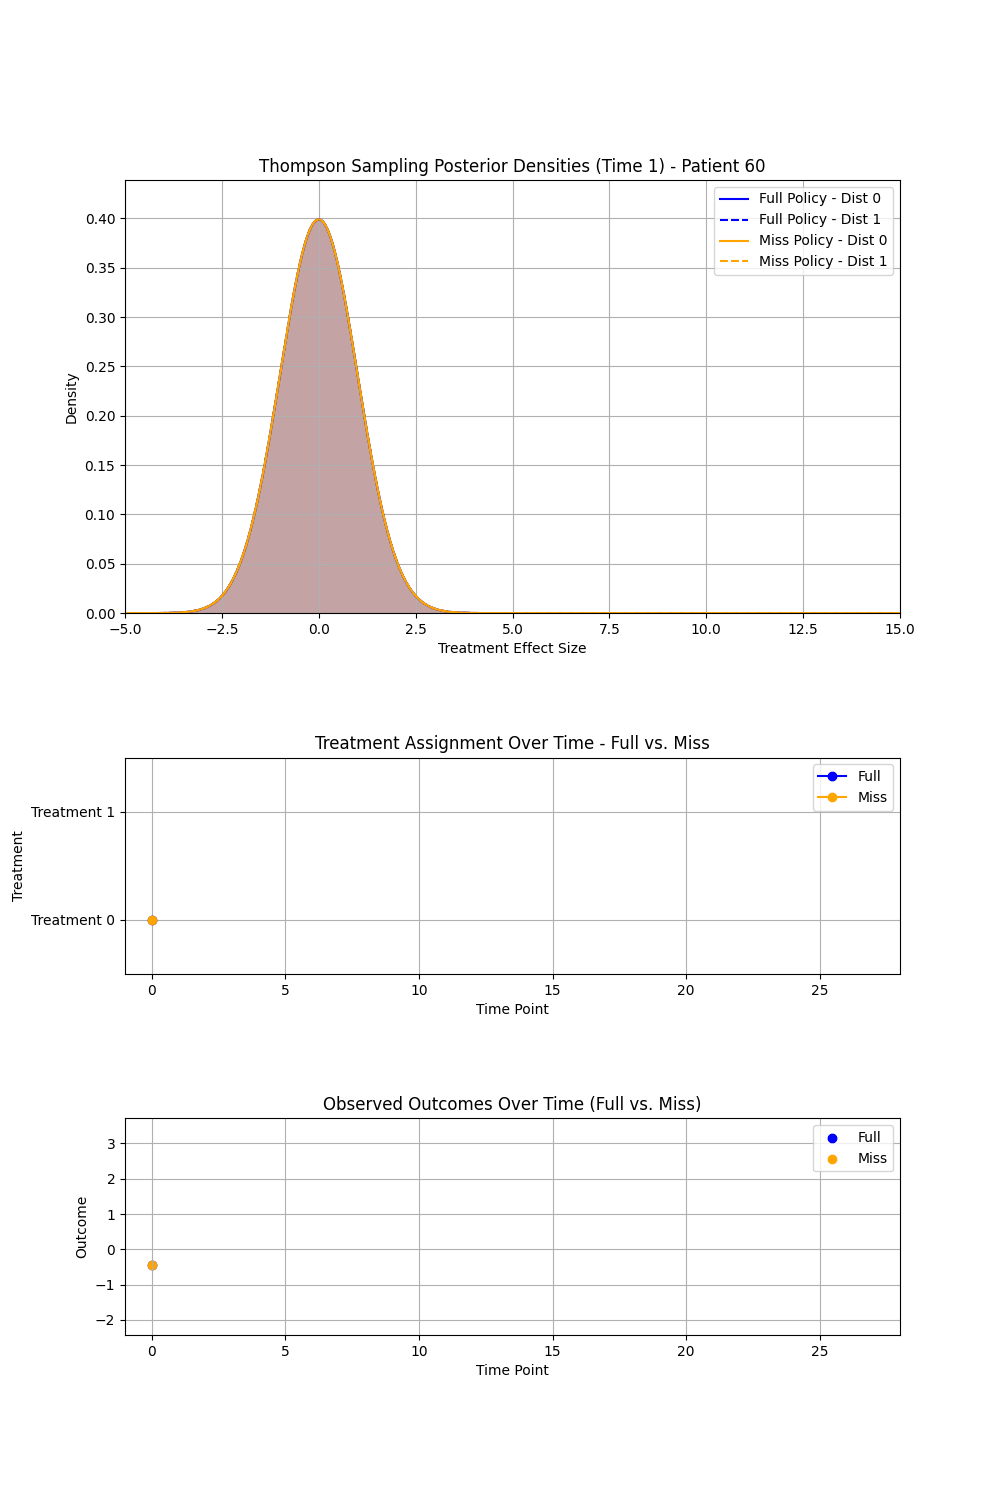

In [37]:
# Display the GIF
from IPython.display import display, Image
display(Image(gif_path))

## Retrieve posterior parameters

In [192]:
def return_overall_means_and_variances(df_results):
    final_posteriors_per_patient = df_results.groupby(["method", "patient_id"]).last()[
    [
        "post_mean_0_full", "post_mean_1_full", "post_mean_0_miss", "post_mean_1_miss",
        "post_var_0_full", "post_var_1_full", "post_var_0_miss", "post_var_1_miss"
    ]
]

    # Compute overall mean per method (averaging final per-patient means)
    overall_means = final_posteriors_per_patient.groupby("method").mean()
    
    # Compute overall variance per method: Mean of individual variances + variance of means
    overall_variances = (final_posteriors_per_patient.groupby("method").var() + final_posteriors_per_patient.groupby("method").mean()**2).apply(np.sqrt)

    return overall_means.round(3).filter(like="mean"), overall_variances.round(3).filter(like="var")

## random 1,0

In [193]:
overall_means_random10, overall_variances_random10 = return_overall_means_and_variances(all_dfs["10"]["random"])

In [196]:
overall_variances_random10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.048,0.288,0.089,0.237
dr,0.048,0.288,0.082,0.237
global,0.048,0.288,0.083,0.239
global_tr,0.048,0.288,0.071,0.248
ind_tr,0.048,0.288,0.094,0.250
individual,0.048,0.288,0.085,0.240
knn,0.048,0.288,0.085,0.238
locf,0.048,0.288,0.093,0.243


In [190]:
overall_variances_random10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.002,0.083,0.008,0.056
dr,0.002,0.083,0.007,0.056
global,0.002,0.083,0.007,0.057
global_tr,0.002,0.083,0.005,0.062
ind_tr,0.002,0.083,0.009,0.063
individual,0.002,0.083,0.007,0.057
knn,0.002,0.083,0.007,0.057
locf,0.002,0.083,0.009,0.059


In [100]:
overall_means_random10

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,0.937,-0.124,0.765,0.163
dr,0.937,-0.124,0.779,0.159
global,0.937,-0.124,0.813,0.174
global_tr,0.937,-0.124,0.856,0.107
ind_tr,0.937,-0.124,0.804,0.137
individual,0.937,-0.124,0.811,0.184
knn,0.937,-0.124,0.809,0.185
locf,0.937,-0.124,0.802,0.184


In [106]:
overall_means_random10

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.627,2.376,1.604,2.016
dr,1.627,2.376,1.604,2.015
global,1.627,2.376,1.611,2.043
global_tr,1.627,2.376,1.610,2.045
ind_tr,1.627,2.376,1.588,2.138
individual,1.417,1.431,1.421,1.420
knn,1.627,2.376,1.615,2.028
locf,1.417,1.431,1.414,1.419


## random 2,2

In [204]:
overall_means_random22, overall_variances_random22 = return_overall_means_and_variances(all_dfs["22"]["random"])

In [205]:
overall_variances_random22

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.403,0.392,0.386,0.390
dr,0.403,0.392,0.400,0.392
global,0.403,0.392,0.400,0.393
global_tr,0.403,0.392,0.400,0.393
ind_tr,0.403,0.392,0.416,0.408
individual,0.403,0.392,0.409,0.400
knn,0.403,0.392,0.410,0.400
locf,0.403,0.392,0.407,0.400


In [102]:
overall_variances_random22

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.163,0.154,0.149,0.152
dr,0.163,0.154,0.160,0.154
global,0.163,0.154,0.160,0.154
global_tr,0.163,0.154,0.160,0.154
ind_tr,0.163,0.154,0.173,0.167
individual,0.163,0.154,0.168,0.160
knn,0.163,0.154,0.168,0.160
locf,0.163,0.154,0.166,0.160


In [103]:
overall_means_random22

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.423,1.432,1.413,1.382
dr,1.423,1.432,1.430,1.444
global,1.423,1.432,1.435,1.443
global_tr,1.423,1.432,1.434,1.445
ind_tr,1.423,1.432,1.369,1.377
individual,1.423,1.432,1.422,1.435
knn,1.423,1.432,1.422,1.434
locf,1.423,1.432,1.414,1.436


## linear 1,0

In [198]:
overall_means_linear10, overall_variances_linear10 = return_overall_means_and_variances(all_dfs["10"]["linear"])

In [201]:
overall_variances_linear10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.048,0.287,0.066,0.266
dr,0.048,0.287,0.066,0.266
global,0.048,0.287,0.062,0.265
global_tr,0.048,0.287,0.055,0.276
ind_tr,0.048,0.287,0.065,0.276
individual,0.048,0.287,0.062,0.269
knn,0.048,0.287,0.062,0.268
locf,0.048,0.287,0.068,0.270


In [112]:
overall_variances_linear10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.002,0.083,0.004,0.071
dr,0.002,0.083,0.004,0.071
global,0.002,0.083,0.004,0.070
global_tr,0.002,0.083,0.003,0.076
ind_tr,0.002,0.083,0.004,0.076
individual,0.002,0.083,0.004,0.073
knn,0.002,0.083,0.004,0.072
locf,0.002,0.083,0.005,0.073


In [113]:
overall_means_linear10

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,0.938,-0.123,0.813,0.031
dr,0.938,-0.123,0.814,0.031
global,0.938,-0.123,0.862,0.048
global_tr,0.938,-0.123,0.898,-0.020
ind_tr,0.938,-0.123,0.874,0.009
individual,0.938,-0.123,0.859,0.048
knn,0.938,-0.123,0.858,0.052
locf,0.938,-0.123,0.864,0.052


## linear 2,2

In [207]:
overall_means_linear22, overall_variances_linear22 = return_overall_means_and_variances(all_dfs["22"]["linear"])

In [208]:
overall_variances_linear22

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.402,0.395,0.404,0.406
dr,0.402,0.395,0.408,0.406
global,0.402,0.395,0.408,0.406
global_tr,0.402,0.395,0.408,0.406
ind_tr,0.402,0.395,0.414,0.411
individual,0.402,0.395,0.408,0.408
knn,0.402,0.395,0.407,0.408
locf,0.402,0.395,0.408,0.403


In [46]:
overall_variances_linear22

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.162,0.156,0.163,0.165
dr,0.162,0.156,0.166,0.164
global,0.162,0.156,0.166,0.165
global_tr,0.162,0.156,0.166,0.165
ind_tr,0.162,0.156,0.171,0.169
individual,0.162,0.156,0.167,0.167
knn,0.162,0.156,0.166,0.167
locf,0.162,0.156,0.166,0.162


In [47]:
overall_means_linear22

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.424,1.423,1.418,1.403
dr,1.424,1.423,1.412,1.415
global,1.424,1.423,1.416,1.417
global_tr,1.424,1.423,1.415,1.417
ind_tr,1.424,1.423,1.380,1.387
individual,1.424,1.423,1.418,1.405
knn,1.424,1.423,1.420,1.404
locf,1.424,1.423,1.412,1.405


## Exponential 2,2

In [65]:
overall_means_exp22, overall_variances_exp22 = return_overall_means_and_variances(df_all_results_exp22)

In [67]:
overall_variances_exp22

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,NaN,NaN,NaN,NaN
dr,NaN,NaN,NaN,NaN
global,NaN,NaN,NaN,NaN
global_tr,NaN,NaN,NaN,NaN
ind_tr,NaN,NaN,NaN,NaN
individual,0.166,0.154,0.162,0.159
knn,NaN,NaN,NaN,NaN
locf,0.166,0.154,0.161,0.158


In [ ]:
overall_means_exp22

# KL divergence

In [48]:
def kl_divergence_norm(mu_p, sigma_p, mu_q, sigma_q):
    """Compute KL divergence D_KL(P || Q) for two normal distributions."""
    return np.log(sigma_q / sigma_p) + (sigma_p**2 + (mu_p - mu_q)**2) / (2 * sigma_q**2) - 0.5

In [49]:
def return_kl_divergence(df_results, true_mu_0, true_sigma_0, true_mu_1,true_sigma_1):

    # Group by method
    kl_results = []
    
    for method, group in df_results.groupby("method"):
        # Compute means and variances for full and miss, 0 and 1
        mu_0_full = group["post_mean_0_full"].mean()
        sigma_0_full = np.sqrt(group["post_var_0_full"].mean())
        
        mu_1_full = group["post_mean_1_full"].mean()
        sigma_1_full = np.sqrt(group["post_var_1_full"].mean())
    
        mu_0_miss = group["post_mean_0_miss"].mean()
        sigma_0_miss = np.sqrt(group["post_var_0_miss"].mean())
        
        mu_1_miss = group["post_mean_1_miss"].mean()
        sigma_1_miss = np.sqrt(group["post_var_1_miss"].mean())
    
        # Compute KL divergence for each case
        kl_0_full_miss = kl_divergence_norm(mu_0_miss, sigma_0_miss, mu_0_full, sigma_0_full)
        kl_1_full_miss = kl_divergence_norm(mu_1_miss, sigma_1_miss, mu_1_full, sigma_1_full)
    
        kl_0_miss_true = kl_divergence_norm(mu_0_miss, sigma_0_miss, true_mu_0, true_sigma_0)
        kl_1_miss_true = kl_divergence_norm(mu_1_miss, sigma_1_miss, true_mu_1, true_sigma_1)
        
        kl_0_full_true = kl_divergence_norm(mu_0_full, sigma_0_full, true_mu_0, true_sigma_0)
        kl_1_full_true = kl_divergence_norm(mu_1_full, sigma_1_full, true_mu_1, true_sigma_1)
    
        # Store results
        kl_results.append({
            "method": method,
            "KL_0_Full_Miss": kl_0_full_miss,
            "KL_1_Full_Miss": kl_1_full_miss,
            "KL_0_Miss_True": kl_0_miss_true,
            "KL_1_Miss_True": kl_1_miss_true,
            "KL_0_Full_True": kl_0_full_true,
            "KL_1_Full_True": kl_1_full_true,
        })
    
    # Convert results to DataFrame
    df_kl_results = pd.DataFrame(kl_results)

    return df_kl_results


In [224]:
klr10 = return_kl_divergence(all_dfs["10"]["random"], 1, 1, 0,1)

In [223]:
kll10 = return_kl_divergence(all_dfs["10"]["linear"], 1, 1, 0,1)

In [222]:
kll22 = return_kl_divergence(all_dfs["22"]["linear"], 1, 1, 0,1)

In [221]:
klr22 = return_kl_divergence(all_dfs["22"]["random"], 2, 1, 2,1)

In [225]:
klr10.round(3)

,method,KL_0_Full_Miss,KL_1_Full_Miss,KL_0_Miss_True,KL_1_Miss_True,KL_0_Full_True,KL_1_Full_True
0,cluster,0.055,0.051,0.434,0.223,0.427,0.184
1,dr,0.041,0.050,0.434,0.220,0.427,0.184
2,global,0.029,0.054,0.427,0.221,0.427,0.184
3,global_tr,0.012,0.031,0.426,0.206,0.427,0.184
4,ind_tr,0.029,0.040,0.423,0.211,0.427,0.184
5,individual,0.031,0.057,0.427,0.221,0.427,0.184
6,knn,0.031,0.058,0.427,0.221,0.427,0.184
7,locf,0.033,0.057,0.424,0.220,0.427,0.184


In [226]:
klr22.round(3)

,method,KL_0_Full_Miss,KL_1_Full_Miss,KL_0_Miss_True,KL_1_Miss_True,KL_0_Full_True,KL_1_Full_True
0,cluster,0.001,0.003,0.541,0.552,0.518,0.51
1,dr,0.000,0.000,0.517,0.501,0.518,0.51
2,global,0.000,0.000,0.514,0.501,0.518,0.51
3,global_tr,0.000,0.000,0.515,0.501,0.518,0.51
4,ind_tr,0.001,0.002,0.540,0.534,0.518,0.51
5,individual,0.000,0.000,0.517,0.504,0.518,0.51
6,knn,0.000,0.000,0.517,0.505,0.518,0.51
7,locf,0.000,0.000,0.521,0.506,0.518,0.51


In [227]:
kll10.round(3)

,method,KL_0_Full_Miss,KL_1_Full_Miss,KL_0_Miss_True,KL_1_Miss_True,KL_0_Full_True,KL_1_Full_True
0,cluster,0.014,0.010,0.435,0.193,0.427,0.184
1,dr,0.013,0.010,0.434,0.193,0.427,0.184
2,global,0.007,0.012,0.430,0.193,0.427,0.184
3,global_tr,0.002,0.005,0.428,0.188,0.427,0.184
4,ind_tr,0.004,0.007,0.426,0.189,0.427,0.184
5,individual,0.007,0.011,0.429,0.192,0.427,0.184
6,knn,0.007,0.012,0.429,0.192,0.427,0.184
7,locf,0.006,0.011,0.426,0.191,0.427,0.184


In [228]:
kll22.round(3)

,method,KL_0_Full_Miss,KL_1_Full_Miss,KL_0_Miss_True,KL_1_Miss_True,KL_0_Full_True,KL_1_Full_True
0,cluster,0.000,0.0,0.174,0.857,0.175,0.867
1,dr,0.000,0.0,0.170,0.872,0.175,0.867
2,global,0.000,0.0,0.170,0.872,0.175,0.867
3,global_tr,0.000,0.0,0.170,0.873,0.175,0.867
4,ind_tr,0.001,0.0,0.166,0.853,0.175,0.867
5,individual,0.000,0.0,0.171,0.861,0.175,0.867
6,knn,0.000,0.0,0.171,0.860,0.175,0.867
7,locf,0.000,0.0,0.172,0.863,0.175,0.867


## Percentage of optimal treatment selection

In [52]:
def return_percentage_optimal_treatment(df_all_results):
    optimal_miss_perc2 = df_all_results.groupby(['method', 'patient_id'])['treatment_miss']\
    .value_counts(normalize=True)\
    .unstack()\
    .mul(100)\
    .fillna(0)

    # Compute mean and standard deviation per method
    summary_miss = optimal_miss_perc2.groupby("method").agg(["mean", "std"]).round(2)
    
    # Rename columns for clarity
    summary_miss.columns = ["percentage_miss_0_mean", "percentage_miss_0_std", "percentage_miss_1_mean", "percentage_miss_1_std"]
    
    # Reset index for readability
    summary_miss = summary_miss.reset_index()
    
    optimal_perc2 = df_all_results.groupby(['method', 'patient_id'])['treatment']\
        .value_counts(normalize=True)\
        .unstack()\
        .mul(100)\
        .fillna(0)

    # Compute mean and standard deviation per method
    summary_full = optimal_perc2.groupby("method").agg(["mean", "std"]).round(2)
    
    # Rename columns for clarity
    summary_full.columns = ["percentage_full_0_mean", "percentage_full_0_std", "percentage_full_1_mean", "percentage_full_1_std"]
    
    # Reset index for readability
    summary_full = summary_full.reset_index()

    return pd.merge(summary_full,summary_miss,on="method")

### random 10

In [209]:
return_percentage_optimal_treatment(all_dfs["10"]["random"]).filter(regex="method|miss_0")

,method,percentage_miss_0_mean,percentage_miss_0_std
0,cluster,69.89,25.41
1,dr,70.84,24.34
2,global,71.46,24.19
3,global_tr,75.26,21.19
4,ind_tr,71.94,25.62
5,individual,70.92,24.42
6,knn,70.92,24.50
7,locf,70.28,25.63


### random 22

In [232]:
# random 22
return_percentage_optimal_treatment(all_dfs["22"]["random"]).filter(regex="method|miss_0")

,method,percentage_miss_0_mean,percentage_miss_0_std
0,cluster,50.64,39.15
1,dr,49.22,38.71
2,global,49.37,38.76
3,global_tr,49.26,38.75
4,ind_tr,49.99,40.11
5,individual,49.55,38.94
6,knn,49.54,38.93
7,locf,49.34,39.05


### linear 10

In [132]:
# linear 10
return_percentage_optimal_treatment(df_all_results_linear10).filter(regex="method|miss_0")

,method,percentage_miss_0_mean,percentage_miss_0_std
0,cluster,77.70,19.95
1,dr,77.74,19.90
2,global,78.39,19.04
3,global_tr,80.75,16.77
4,ind_tr,78.74,19.91
5,individual,78.17,19.46
6,knn,78.10,19.49
7,locf,77.70,20.44


## linear 22

In [233]:
# linear 22
return_percentage_optimal_treatment(all_dfs["22"]["linear"]).filter(regex="method|miss_0")

,method,percentage_miss_0_mean,percentage_miss_0_std
0,cluster,49.61,39.06
1,dr,49.08,39.04
2,global,49.05,39.03
3,global_tr,49.05,39.03
4,ind_tr,49.16,39.68
5,individual,49.51,39.15
6,knn,49.55,39.15
7,locf,49.54,39.06


In [234]:
# linear 22
return_percentage_optimal_treatment(all_dfs["22"]["linear"]).filter(regex="method|full_0")

,method,percentage_full_0_mean,percentage_full_0_std
0,cluster,49.58,38.91
1,dr,49.58,38.91
2,global,49.58,38.91
3,global_tr,49.58,38.91
4,ind_tr,49.58,38.91
5,individual,49.58,38.91
6,knn,49.58,38.91
7,locf,49.58,38.91


In [231]:
# random 22
return_percentage_optimal_treatment(all_dfs["22"]["random"]).filter(regex="method|full_0")

,method,percentage_full_0_mean,percentage_full_0_std
0,cluster,49.47,38.88
1,dr,49.47,38.88
2,global,49.47,38.88
3,global_tr,49.47,38.88
4,ind_tr,49.47,38.88
5,individual,49.47,38.88
6,knn,49.47,38.88
7,locf,49.47,38.88


In [236]:
# linear 22
return_percentage_optimal_treatment(all_dfs["10"]["linear"]).filter(regex="method|full_0")

,method,percentage_full_0_mean,percentage_full_0_std
0,cluster,83.52,13.53
1,dr,83.52,13.53
2,global,83.52,13.53
3,global_tr,83.52,13.53
4,ind_tr,83.52,13.53
5,individual,83.52,13.53
6,knn,83.52,13.53
7,locf,83.52,13.53


In [235]:
# random 22
return_percentage_optimal_treatment(all_dfs["10"]["random"]).filter(regex="method|full_0")

,method,percentage_full_0_mean,percentage_full_0_std
0,cluster,83.31,13.82
1,dr,83.31,13.82
2,global,83.31,13.82
3,global_tr,83.31,13.82
4,ind_tr,83.31,13.82
5,individual,83.31,13.82
6,knn,83.31,13.82
7,locf,83.31,13.82


### exponential 10

### exponential 22

# Longer sequences sensitivity analysis

## double length 1,0

In [32]:
overall_means_dl10, overall_variances_dl10 = return_overall_means_and_variances(df_all_results_dl10)

In [23]:
overall_variances_dl10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.0,0.055,0.003,0.031
dr,0.0,0.055,0.002,0.031
global,0.0,0.055,0.002,0.031
global_tr,0.0,0.055,0.001,0.035
ind_tr,0.0,0.055,0.003,0.033
individual,0.0,0.055,0.003,0.029
knn,0.0,0.055,0.002,0.029
locf,0.0,0.055,0.003,0.031


In [33]:
overall_means_dl10

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,0.944,-0.156,0.811,0.209
dr,0.944,-0.156,0.821,0.214
global,0.944,-0.156,0.846,0.237
global_tr,0.944,-0.156,0.900,0.131
ind_tr,0.944,-0.156,0.843,0.187
individual,0.944,-0.156,0.840,0.249
knn,0.944,-0.156,0.854,0.252
locf,0.944,-0.156,0.837,0.242


## 100 linear 1,0

In [27]:
overall_means_dl10, overall_variances_dl10 = return_overall_means_and_variances(df_all_results_dl10)

In [28]:
overall_variances_dl10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.0,0.049,0.001,0.036
dr,0.0,0.049,0.001,0.036
global,0.0,0.049,0.001,0.037
global_tr,0.0,0.049,0.000,0.039
ind_tr,0.0,0.049,0.001,0.040
individual,0.0,0.049,0.001,0.037
knn,0.0,0.049,0.001,0.037
locf,0.0,0.049,0.001,0.038


In [29]:
overall_means_dl10

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,0.97,-0.159,0.864,0.085
dr,0.97,-0.159,0.862,0.083
global,0.97,-0.159,0.906,0.084
global_tr,0.97,-0.159,0.924,0.035
ind_tr,0.97,-0.159,0.907,0.030
individual,0.97,-0.159,0.903,0.088
knn,0.97,-0.159,0.908,0.094
locf,0.97,-0.159,0.896,0.086


## double length 2,2

In [15]:
overall_means_dl22, overall_variances_dl22 = return_overall_means_and_variances(df_all_results_dl22)

In [16]:
overall_variances_dl22

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.051,0.077,0.048,0.073
dr,0.051,0.077,0.049,0.058
global,0.051,0.077,0.048,0.063
global_tr,0.051,0.077,0.049,0.062
ind_tr,0.051,0.077,0.058,0.084
individual,0.051,0.077,0.048,0.069
knn,0.051,0.077,0.048,0.069
locf,0.051,0.077,0.054,0.059


In [17]:
overall_means_dl22

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.551,1.608,1.571,1.578
dr,1.551,1.608,1.558,1.686
global,1.551,1.608,1.571,1.663
global_tr,1.551,1.608,1.561,1.670
ind_tr,1.551,1.608,1.474,1.536
individual,1.551,1.608,1.557,1.668
knn,1.551,1.608,1.563,1.673
locf,1.551,1.608,1.520,1.672


## 100 linear 2,2

In [36]:
overall_means_dl10, overall_variances_dl10 = return_overall_means_and_variances(df_all_results_dl10)

In [37]:
overall_variances_dl10

,post_var_0_full,post_var_1_full,post_var_0_miss,post_var_1_miss
method,,,,
cluster,0.03,0.033,0.018,0.042
dr,0.03,0.033,0.018,0.041
global,0.03,0.033,0.018,0.042
global_tr,0.03,0.033,0.018,0.042
ind_tr,0.03,0.033,0.024,0.042
individual,0.03,0.033,0.019,0.040
knn,0.03,0.033,0.018,0.042
locf,0.03,0.033,0.019,0.037


In [38]:
overall_means_dl10

,post_mean_0_full,post_mean_1_full,post_mean_0_miss,post_mean_1_miss
method,,,,
cluster,1.678,1.687,1.696,1.674
dr,1.678,1.687,1.700,1.681
global,1.678,1.687,1.703,1.685
global_tr,1.678,1.687,1.698,1.687
ind_tr,1.678,1.687,1.609,1.690
individual,1.678,1.687,1.684,1.693
knn,1.678,1.687,1.694,1.694
locf,1.678,1.687,1.663,1.724


## Some checks

## Check results

In [2]:
import pandas as pd

In [5]:
df_all_results = pd.read_pickle(f"{calculated_series_path}/df_all_results.pkl")

In [7]:
df_all_results= df_all_results.loc[:, ~df_all_results.columns.duplicated(keep='first')]

In [5]:
import pandas as pd

# Check if 'outcome' and 'outcome_miss' are identical where 'missing' is False
identical_when_not_missing = (
    df_all_results.loc[df_all_results["missing"] == False, "outcome"] ==
    df_all_results.loc[df_all_results["missing"] == False, "outcome_miss"]
).all()

# Check if 'outcome' and 'outcome_miss' are different where 'missing' is True
different_when_missing = (
    df_all_results.loc[df_all_results["missing"] == True, "outcome"] !=
    df_all_results.loc[df_all_results["missing"] == True, "outcome_miss"]
).all()

# Print the results
print("Are 'outcome' and 'outcome_miss' identical when missing == False?", identical_when_not_missing)
print("Are 'outcome' and 'outcome_miss' different when missing == True?", different_when_missing)


Are 'outcome' and 'outcome_miss' identical when missing == False? True
Are 'outcome' and 'outcome_miss' different when missing == True? True


# Results - outcome means

In [12]:
# random 10
df_all_results.groupby(["method","treatment"])["outcome"].mean()

method      treatment
global      0            0.938270
            1           -0.042456
individual  0            0.938270
            1           -0.042456
Name: outcome, dtype: float64

In [13]:
# random 10
df_all_results.groupby(["method","treatment_miss"])["outcome_miss"].mean()

method      treatment_miss
global      0                 0.870465
            1                 0.468865
individual  0                 0.865779
            1                 0.496223
Name: outcome_miss, dtype: float64

In [24]:
# random 10
df_all_results.groupby(["method","treatment"])["outcome"].mean()

method      treatment
cluster     0            1.002260
            1            0.014626
global      0            1.002260
            1            0.014626
global_tr   0            1.002260
            1            0.014626
ind_tr      0            1.002260
            1            0.014626
individual  0            1.002260
            1            0.014626
knn         0            1.002260
            1            0.014626
locf        0            1.002260
            1            0.014626
Name: outcome, dtype: float64

In [46]:
# random 22
df_all_results.groupby(["method","treatment"])["outcome"].mean()

method      treatment
global      0            2.015924
            1            1.992746
global_tr   0            2.015924
            1            1.992746
ind_tr      0            2.015924
            1            1.992746
individual  0            2.015924
            1            1.992746
locf        0            2.015924
            1            1.992746
Name: outcome, dtype: float64

In [47]:
# random 22
df_all_results.groupby(["method","treatment_miss"])["outcome_miss"].mean()

method      treatment_miss
global      0                 2.014941
            1                 1.990898
global_tr   0                 2.018313
            1                 1.986583
ind_tr      0                 2.039158
            1                 1.996404
individual  0                 2.024406
            1                 1.991852
locf        0                 2.023491
            1                 1.991772
Name: outcome_miss, dtype: float64

## Discard

In [58]:
posterior_params_full = []
for imputation in imputation_method_names:
    posterior_params_full.append(pd.Series(all_calcs[imputation][0]["configuration"]["policy_full"]))

In [30]:
posterior_params_miss = []
for imputation in imputation_method_names:
    posterior_params_miss.append(pd.Series(all_calcs[imputation][0]["configuration"]["policy_miss"]))

In [81]:
post_params_miss = return_post_params_table(posterior_params_miss,posterior_params_full)

In [59]:
post_params_full = return_post_params_table(posterior_params_full,suffix="full")

In [82]:
post_params_miss

,imputation_method,mean_0,mean_1,variance_0,variance_1
0,full,1.175005,0.432548,0.043478,0.166667
0,locf,0.337961,1.509718,0.111111,0.050000
1,individual,0.902634,1.169507,0.055556,0.090909
2,global,0.993200,1.098040,0.055556,0.090909
3,ind_tr,0.965578,1.188990,0.055556,0.090909
4,global_tr,0.993200,1.098040,0.055556,0.090909
5,knn,0.949714,1.147474,0.055556,0.090909
6,cluster,0.973695,1.149516,0.055556,0.090909
7,dr,0.936322,1.138054,0.055556,0.090909


In [19]:
all_calcs["global"][0]["configuration"]["policy_full"]

([1.175004750634259, 0.4325476253795955],
 [0.043478260869565216, 0.16666666666666666])

In [20]:
all_calcs["global"][0]["configuration"]["policy_miss"]

([0.9931995900977194, 1.0980400209978185],
 [0.05555555555555555, 0.09090909090909091])

In [66]:
miss_ids = df_all_results[df_all_results["missing"]==True].groupby("method")["patient_id"].unique()

In [67]:
for i in range(len(miss_ids)):
    miss_ids.iloc[i] = np.sort(miss_ids[i])

/tmp/ipykernel_1129/1125615409.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  miss_ids.iloc[i] = np.sort(miss_ids[i])


In [68]:
miss_ids

method
cluster       [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
dr            [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
global        [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
global_tr     [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
ind_tr        [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
individual    [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
knn           [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
locf          [0, 1, 2, 5, 7, 8, 9, 10, 12, 13, 16, 19, 20, ...
Name: patient_id, dtype: object

In [69]:
total_counts = df_all_results.groupby(["method","patient_id"])["missing"].count()

# Step 2: Count occurrences where missing == True
missing_counts = df_all_results.groupby(["method","patient_id"])["missing"].sum()  # sum() works since True=1, False=0

# Step 3: Compute percentage (only for patients who have at least one True)
missing_percentage = (missing_counts / total_counts) * 100
missing_percentage = missing_percentage[missing_counts > 0].reset_index()
#missing_percentage.columns = ["patient_id", "missing_percentage"]

print(missing_percentage["missing"].value_counts())

missing
28.571429    4000
Name: count, dtype: int64


In [70]:
imba_ids = missing_percentage[["patient_id","missing"]].drop_duplicates(keep=False)["patient_id"]
imba_ids

Series([], Name: patient_id, dtype: int64)

In [71]:
(df_all_results[df_all_results["missing"]]
    .groupby("method")["patient_id"]
    .nunique()
    .reset_index(name="num_patients_with_missing"))

,method,num_patients_with_missing
0,cluster,500
1,dr,500
2,global,500
3,global_tr,500
4,ind_tr,500
5,individual,500
6,knn,500
7,locf,500
